In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/imsparsh/flowers-dataset/sample_submission.csv
/kaggle/input/datasets/imsparsh/flowers-dataset/Testing_set_flower.csv
/kaggle/input/datasets/imsparsh/flowers-dataset/LICENSE.txt
/kaggle/input/datasets/imsparsh/flowers-dataset/test/Image_747.jpg
/kaggle/input/datasets/imsparsh/flowers-dataset/test/Image_561.jpg
/kaggle/input/datasets/imsparsh/flowers-dataset/test/Image_345.jpg
/kaggle/input/datasets/imsparsh/flowers-dataset/test/Image_844.jpg
/kaggle/input/datasets/imsparsh/flowers-dataset/test/Image_270.jpg
/kaggle/input/datasets/imsparsh/flowers-dataset/test/Image_526.jpg
/kaggle/input/datasets/imsparsh/flowers-dataset/test/Image_322.jpg
/kaggle/input/datasets/imsparsh/flowers-dataset/test/Image_860.jpg
/kaggle/input/datasets/imsparsh/flowers-dataset/test/Image_574.jpg
/kaggle/input/datasets/imsparsh/flowers-dataset/test/Image_879.jpg
/kaggle/input/datasets/imsparsh/flowers-dataset/test/Image_22.jpg
/kaggle/input/datasets/imsparsh/flowers-dataset/test/Image_486.

## Import Libraries

In [2]:
import numpy as np
import pandas as pd
import os
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("Libraries imported successfully")

Libraries imported successfully


In [3]:
for root, dirs, files in os.walk("/kaggle/input"):
    print(root)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/imsparsh
/kaggle/input/datasets/imsparsh/flowers-dataset
/kaggle/input/datasets/imsparsh/flowers-dataset/test
/kaggle/input/datasets/imsparsh/flowers-dataset/train
/kaggle/input/datasets/imsparsh/flowers-dataset/train/dandelion
/kaggle/input/datasets/imsparsh/flowers-dataset/train/daisy
/kaggle/input/datasets/imsparsh/flowers-dataset/train/sunflower
/kaggle/input/datasets/imsparsh/flowers-dataset/train/tulip
/kaggle/input/datasets/imsparsh/flowers-dataset/train/rose


## Set Dataset Path

In [4]:
dataset_path = "/kaggle/input/datasets/imsparsh/flowers-dataset/train"

categories = os.listdir(dataset_path)
print("Categories:", categories)

for category in categories:
    folder = os.path.join(dataset_path, category)
    print(category, "->", len(os.listdir(folder)), "images")

Categories: ['dandelion', 'daisy', 'sunflower', 'tulip', 'rose']
dandelion -> 646 images
daisy -> 501 images
sunflower -> 495 images
tulip -> 607 images
rose -> 497 images


## Load and Preprocess Images

In [5]:
IMG_SIZE = 224

data = []
labels = []

for category in categories:
    folder = os.path.join(dataset_path, category)
    for img_name in os.listdir(folder):
        try:
            img_path = os.path.join(folder, img_name)
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            data.append(img)
            labels.append(category)
        except Exception as e:
            print("Error loading:", img_path)

data = np.array(data)
print("Data shape:", data.shape)
print("Total labels:", len(labels))

Data shape: (2746, 224, 224, 3)
Total labels: 2746


## Encode Labels and Split Data

In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
labels_encoded = le.fit_transform(labels)
labels_categorical = to_categorical(labels_encoded)

print("Classes:", le.classes_)

X_train, X_test, y_train, y_test = train_test_split(
    data, labels_categorical, test_size=0.2, random_state=42, stratify=labels_categorical
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train = preprocess_input(X_train.astype('float32'))
X_test = preprocess_input(X_test.astype('float32'))

Classes: ['daisy' 'dandelion' 'rose' 'sunflower' 'tulip']
X_train shape: (2196, 224, 224, 3)
X_test shape: (550, 224, 224, 3)


## Build ResNet-50 Model (Transfer Learning)

In [7]:
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))

base_model.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(5, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

I0000 00:00:1787571977.238686      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1787571977.241856      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,113,541 (91.99 MB)

 Trainable params: 525,829 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

## Train the Model

In [8]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32
)

Epoch 1/10
 1/69 ━━━━━━━━━━━━━━━━━━━━ 16:22 14s/step - accuracy: 0.3125 - loss: 2.5285

I0000 00:00:1787571998.283071     132 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


69/69 ━━━━━━━━━━━━━━━━━━━━ 35s 295ms/step - accuracy: 0.5487 - loss: 1.2209 - val_accuracy: 0.8109 - val_loss: 0.5437
Epoch 2/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 7s 102ms/step - accuracy: 0.7933 - loss: 0.5656 - val_accuracy: 0.8564 - val_loss: 0.4167
Epoch 3/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 7s 103ms/step - accuracy: 0.8411 - loss: 0.4303 - val_accuracy: 0.8655 - val_loss: 0.3555
Epoch 4/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 7s 103ms/step - accuracy: 0.8857 - loss: 0.3386 - val_accuracy: 0.8745 - val_loss: 0.3318
Epoch 5/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 7s 104ms/step - accuracy: 0.8948 - loss: 0.3021 - val_accuracy: 0.8818 - val_loss: 0.3072
Epoch 6/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 7s 106ms/step - accuracy: 0.9148 - loss: 0.2534 - val_accuracy: 0.8909 - val_loss: 0.2961
Epoch 7/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 7s 106ms/step - accuracy: 0.9230 - loss: 0.2172 - val_accuracy: 0.8891 - val_loss: 0.2859
Epoch 8/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 7s 107ms/step - accuracy: 0.9372 - loss: 0.1822 - val_accuracy: 0.9000 - val

## Evaluate Model and Plot Results

18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - accuracy: 0.8945 - loss: 0.2833
Test Accuracy: 89.45%


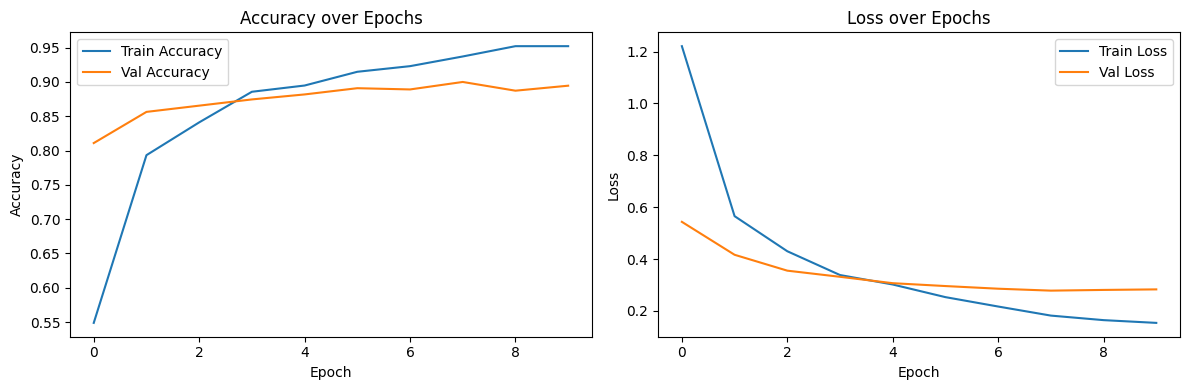

In [9]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy*100:.2f}%")

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

## Save the Model

In [10]:
model.save("flowers_resnet50_model.keras")
print("Model saved successfully!")

Model saved successfully!


## Build Simple Prediction API

In [11]:
!pip install fastapi uvicorn pyngrok nest-asyncio

## Load Saved Model for API

In [14]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing import image as keras_image

# Load the saved model
loaded_model = tf.keras.models.load_model("flowers_resnet50_model.keras")
print("Model loaded successfully!")

Model loaded successfully!


## Create FastAPI Prediction Endpoint

In [15]:
from fastapi import FastAPI, File, UploadFile
from PIL import Image
import io

app = FastAPI()

@app.get("/")
def home():
    return {"message": "Flower Classification API is running"}

@app.post("/predict")
async def predict(file: UploadFile = File(...)):
    contents = await file.read()
    img = Image.open(io.BytesIO(contents)).convert("RGB")
    img = img.resize((224, 224))
    img_array = keras_image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    prediction = loaded_model.predict(img_array)
    class_names = ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
    predicted_class = class_names[np.argmax(prediction)]
    confidence = float(np.max(prediction))

    return {"predicted_class": predicted_class, "confidence": confidence}

print("API code ready!")

API code ready!


## Run the API with Ngrok

In [18]:
import threading

def run_api():
    uvicorn.run(app, host="0.0.0.0", port=8000)

thread = threading.Thread(target=run_api)
thread.start()

print("API is starting... Public URL:", public_url)

API is starting... Public URL: NgrokTunnel: "https://monorail-prescribe-kooky.ngrok-free.dev" -> "http://localhost:8000"


INFO:     Started server process [58]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


## Test the API

In [19]:
import requests

# Pick any test image from the dataset
test_img_path = "/kaggle/input/datasets/imsparsh/flowers-dataset/train/rose/" + os.listdir("/kaggle/input/datasets/imsparsh/flowers-dataset/train/rose")[0]

with open(test_img_path, "rb") as img_file:
    response = requests.post(
        "http://localhost:8000/predict",
        files={"file": img_file}
    )

print("Status Code:", response.status_code)
print("Prediction:", response.json())

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
INFO:     127.0.0.1:33140 - "POST /predict HTTP/1.1" 200 OK
Status Code: 200
Prediction: {'predicted_class': 'tulip', 'confidence': 0.9157359004020691}
